In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mfhussainfa","key":"d9890d6d282c268a00aa30c20c38d9a4"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets list

ref                                                   title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                              Heart Disease                                   3491  2025-12-11 15:29:14.327000           2114        153  1.0              
neurocipher/student-performance                       Student Performance                            49705  2025-12-12 12:06:28.973000           1261        103  1.0              
dansbecker/melbourne-housing-snapshot                 Melbourne Housing Snapshot                    461423  2018-06-05 12:52:24.087000         200095       1719  0.7058824        
datasnaek/chess                                       Chess Game Dataset (Lichess)                 2

In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:21<00:00, 202MB/s]
100% 2.29G/2.29G [00:21<00:00, 113MB/s]


In [6]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [7]:
!ls chest_xray

chest_xray  __MACOSX  test  train  val


In [8]:
!ls chest_xray/train

NORMAL	PNEUMONIA


In [9]:
#Import required PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [10]:
#Define device (CPU / GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [11]:
#Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [12]:
#Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(
    root="chest_xray/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root="chest_xray/val",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="chest_xray/test",
    transform=transform
)


In [13]:
#Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [14]:
#Check class labels
print(train_dataset.class_to_idx)


{'NORMAL': 0, 'PNEUMONIA': 1}


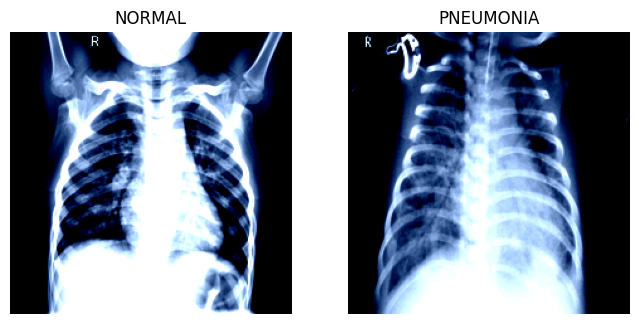

In [15]:
# Visualize one NORMAL and one PNEUMONIA sample
for i in range(len(train_dataset)):
    img, label = train_dataset[i]
    if label == 0:
        normal_img = img
        break

for i in range(len(train_dataset)):
    img, label = train_dataset[i]
    if label == 1:
        pneumonia_img = img
        break

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(np.transpose(normal_img.numpy(), (1,2,0)))
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(np.transpose(pneumonia_img.numpy(), (1,2,0)))
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()


In [16]:
#Baseline CNN
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [17]:
#Initialize model, loss, optimizer
model_cnn = BaselineCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.0001)


In [18]:
#Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = torch.sigmoid(outputs) > 0.5
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


In [19]:
#Train the CNN
train_model(
    model_cnn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)


Epoch [1/5] Train Loss: 49.7352, Train Acc: 0.8587 | Val Loss: 0.6729, Val Acc: 0.6250
Epoch [2/5] Train Loss: 30.4623, Train Acc: 0.9293 | Val Loss: 0.3336, Val Acc: 0.9375
Epoch [3/5] Train Loss: 25.7007, Train Acc: 0.9480 | Val Loss: 0.5239, Val Acc: 0.6875
Epoch [4/5] Train Loss: 24.3218, Train Acc: 0.9578 | Val Loss: 0.3701, Val Acc: 0.8125
Epoch [5/5] Train Loss: 22.2061, Train Acc: 0.9624 | Val Loss: 0.2370, Val Acc: 0.9375


In [20]:
#Evaluate on test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_cnn.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn(images)
        preds = torch.sigmoid(outputs) > 0.5

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


In [21]:
#Print evaluation metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Baseline CNN Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Baseline CNN Performance:
Accuracy : 0.8173
Precision: 0.7816
Recall   : 0.9821
F1-score : 0.8705


In [22]:
#Load pre-trained VGG16
vgg16 = models.vgg16(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 77.1MB/s]


In [23]:
#Freeze convolutional layers
for param in vgg16.features.parameters():
    param.requires_grad = False


In [24]:
#Modify the classifier for binary classification
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)


In [25]:
#Move model to device
model_vgg = vgg16.to(device)


In [26]:
#Define loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_vgg.classifier.parameters(), lr=0.0001)


In [27]:
#Train VGG16
train_model(
    model_vgg,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)


Epoch [1/5] Train Loss: 16.2369, Train Acc: 0.9595 | Val Loss: 0.2579, Val Acc: 0.8125
Epoch [2/5] Train Loss: 6.0297, Train Acc: 0.9872 | Val Loss: 0.0606, Val Acc: 1.0000
Epoch [3/5] Train Loss: 3.9879, Train Acc: 0.9914 | Val Loss: 0.1119, Val Acc: 0.9375
Epoch [4/5] Train Loss: 2.0434, Train Acc: 0.9960 | Val Loss: 0.0414, Val Acc: 1.0000
Epoch [5/5] Train Loss: 1.3577, Train Acc: 0.9979 | Val Loss: 0.0867, Val Acc: 0.9375


In [28]:
#Evaluate VGG16 on test set
model_vgg.eval()
y_true_vgg = []
y_pred_vgg = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_vgg(images)
        preds = torch.sigmoid(outputs) > 0.3

        y_true_vgg.extend(labels.cpu().numpy())
        y_pred_vgg.extend(preds.cpu().numpy())


In [29]:
#Print VGG16 metrics
acc_vgg = accuracy_score(y_true_vgg, y_pred_vgg)
prec_vgg = precision_score(y_true_vgg, y_pred_vgg)
rec_vgg = recall_score(y_true_vgg, y_pred_vgg)
f1_vgg = f1_score(y_true_vgg, y_pred_vgg)

print("VGG16 Performance:")
print(f"Accuracy : {acc_vgg:.4f}")
print(f"Precision: {prec_vgg:.4f}")
print(f"Recall   : {rec_vgg:.4f}")
print(f"F1-score : {f1_vgg:.4f}")


VGG16 Performance:
Accuracy : 0.7420
Precision: 0.7078
Recall   : 1.0000
F1-score : 0.8289


In [30]:
#Load pretrained ResNet50
resnet50 = models.resnet50(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


In [31]:
#Freeze all convolutional layers
for param in resnet50.parameters():
    param.requires_grad = False


In [32]:
#Replace the final fully connected layer
num_features = resnet50.fc.in_features

resnet50.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)


In [33]:
#Move model to device
model_resnet = resnet50.to(device)


In [34]:
#Define loss & optimizer
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model_resnet.fc.parameters(),
    lr=0.0001
)



In [35]:
#Train ResNet50
train_model(
    model_resnet,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)


Epoch [1/5] Train Loss: 57.6847, Train Acc: 0.8441 | Val Loss: 0.4872, Val Acc: 0.6875
Epoch [2/5] Train Loss: 34.4228, Train Acc: 0.9193 | Val Loss: 0.2789, Val Acc: 0.8750
Epoch [3/5] Train Loss: 29.5496, Train Acc: 0.9273 | Val Loss: 0.2685, Val Acc: 0.8750
Epoch [4/5] Train Loss: 26.7954, Train Acc: 0.9365 | Val Loss: 0.2045, Val Acc: 0.9375
Epoch [5/5] Train Loss: 24.7096, Train Acc: 0.9413 | Val Loss: 0.3848, Val Acc: 0.8125


In [36]:
#Evaluate ResNet50 on test set
model_resnet.eval()
y_true_resnet = []
y_pred_resnet = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_resnet(images)
        preds = torch.sigmoid(outputs) > 0.5

        y_true_resnet.extend(labels.cpu().numpy())
        y_pred_resnet.extend(preds.cpu().numpy())


In [37]:
#Print ResNet50 metrics
acc_r = accuracy_score(y_true_resnet, y_pred_resnet)
prec_r = precision_score(y_true_resnet, y_pred_resnet)
rec_r = recall_score(y_true_resnet, y_pred_resnet)
f1_r = f1_score(y_true_resnet, y_pred_resnet)

print("ResNet50 Performance:")
print(f"Accuracy : {acc_r:.4f}")
print(f"Precision: {prec_r:.4f}")
print(f"Recall   : {rec_r:.4f}")
print(f"F1-score : {f1_r:.4f}")


ResNet50 Performance:
Accuracy : 0.7821
Precision: 0.7471
Recall   : 0.9846
F1-score : 0.8496


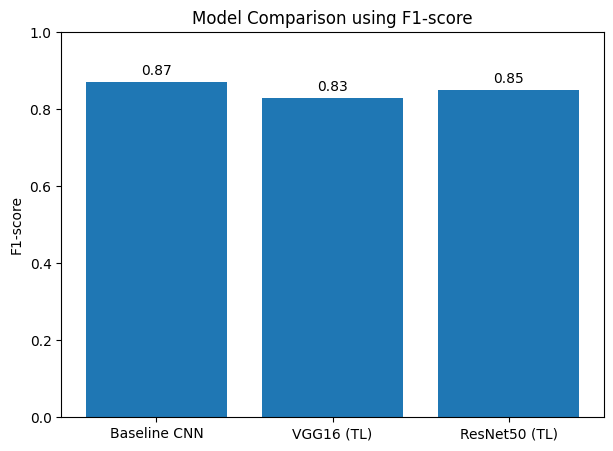

In [38]:
#F1-score comparison plot
import matplotlib.pyplot as plt

models = ["Baseline CNN", "VGG16 (TL)", "ResNet50 (TL)"]
f1_scores = [0.8705, 0.8289, 0.8496]

plt.figure(figsize=(7,5))
bars = plt.bar(models, f1_scores)

plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.title("Model Comparison using F1-score")

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             f"{yval:.2f}", ha='center', va='bottom')

plt.show()


In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [40]:
#Collect predictions and true labels
all_preds = []
all_labels = []

model_cnn.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn(images)

        # Binary prediction (threshold = 0.5)
        preds = (torch.sigmoid(outputs) > 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


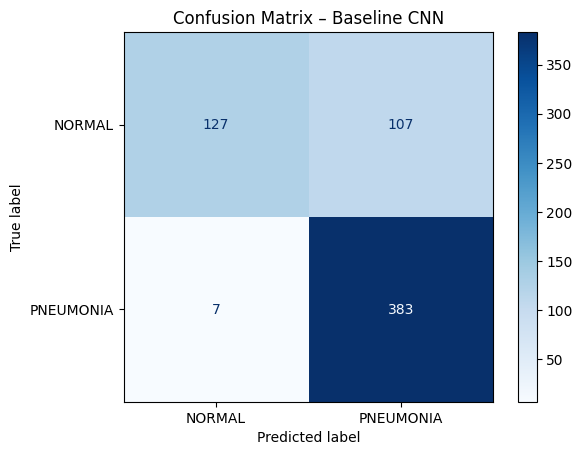

In [41]:
#Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Baseline CNN")
plt.show()


In [42]:
#Install Grad-CAM
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=d72a3c48cb7fa12bd9009cdb77296995ea2053b427cc7da2cb4f4aa428542fec
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [75]:
#model in evaluation mode
model_cnn.eval()


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [76]:
#Select target convolution layer
target_layer = model_cnn.features[-1]


In [77]:
#Load ONE test image
import os
from PIL import Image
from torchvision import transforms

img_path = "chest_xray/test/PNEUMONIA/" + os.listdir("chest_xray/test/PNEUMONIA")[0]

img = Image.open(img_path).convert("RGB")

input_tensor = transform(img).unsqueeze(0).to(device)


In [78]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import torch


In [79]:
cam = GradCAM(
    model=model_cnn,
    target_layers=[target_layer]
)


In [80]:
targets = [BinaryClassifierOutputTarget(1)]


In [81]:
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]


In [82]:
img_np = np.array(img.resize((224,224))) / 255.0

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)


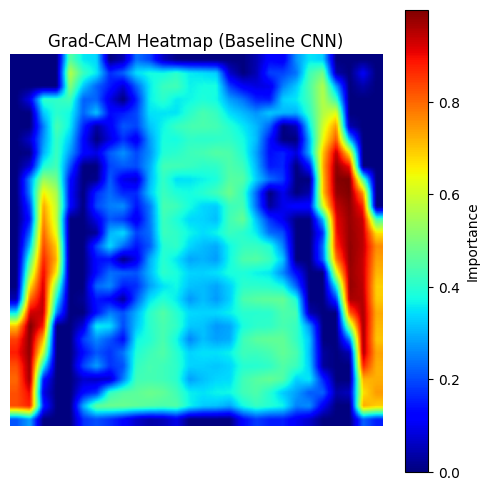

In [83]:
#Visualize heatmap
plt.figure(figsize=(6,6))
plt.imshow(grayscale_cam, cmap='jet')
plt.colorbar(label="Importance")
plt.title("Grad-CAM Heatmap (Baseline CNN)")
plt.axis("off")
plt.show()


In [84]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


In [85]:
model_vgg.eval()


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [86]:
target_layers = [model_vgg.features[28]]


In [87]:
targets = [ClassifierOutputTarget(0)]


In [115]:
cam = GradCAM(
    model=model_vgg,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]


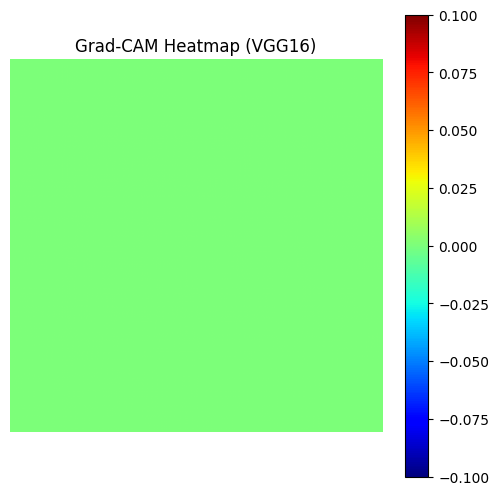

In [116]:
#Visualize heatmap
plt.figure(figsize=(6,6))
plt.imshow(grayscale_cam, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap (VGG16)")
plt.axis("off")
plt.show()


In [89]:
!pip install grad-cam


In [91]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget


In [92]:
#Put model in eval mode & enable gradients
model_resnet.eval()

for param in model_resnet.parameters():
    param.requires_grad = True


In [93]:
#Load ONE test image correctly
from torchvision import transforms
from PIL import Image
import os

img_path = "chest_xray/test/PNEUMONIA/" + os.listdir("chest_xray/test/PNEUMONIA")[0]

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img = Image.open(img_path).convert("RGB")
input_tensor = transform(img).unsqueeze(0).to(device)
input_tensor.requires_grad = True


In [94]:
#Select CORRECT target layer
target_layer = model_resnet.layer4[-1]


In [95]:
#Define target class
targets = [BinaryClassifierOutputTarget(1)]  # 1 = PNEUMONIA


In [96]:
#Run Grad-CAM
cam = GradCAM(
    model=model_resnet,
    target_layers=[target_layer]
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]


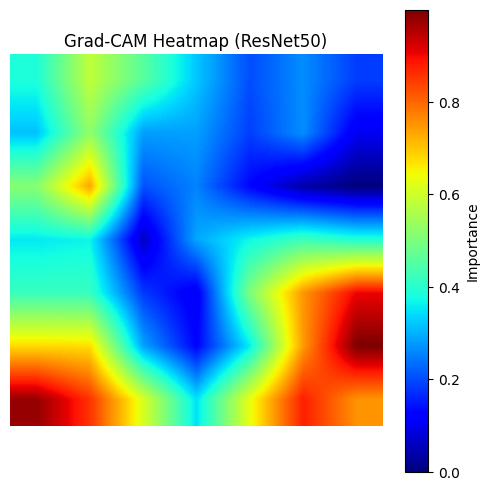

In [97]:
#Visualize heatmap
plt.figure(figsize=(6,6))
plt.imshow(grayscale_cam, cmap="jet")
plt.colorbar(label="Importance")
plt.title("Grad-CAM Heatmap (ResNet50)")
plt.axis("off")
plt.show()


In [98]:
#Install LIME
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=25a55b0e1f3c0a5e5db35503742f40ca7a9dd6ba6f3387b8898f09a4fa3a557e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [99]:
#Imports
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import torch
import matplotlib.pyplot as plt


In [100]:
#prediction function
def predict_fn(images):
    model_cnn.eval()

    images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)

    with torch.no_grad():
        outputs = model_cnn(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

    # Return probabilities for [NORMAL, PNEUMONIA]
    return np.concatenate([1 - probs, probs], axis=1)


In [101]:
#Create LIME explainer
explainer = lime_image.LimeImageExplainer()


In [102]:
#Run LIME on ONE image
explanation = explainer.explain_instance(
    img_np,              # original image (224,224,3)
    predict_fn,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)


  0%|          | 0/1000 [00:00<?, ?it/s]

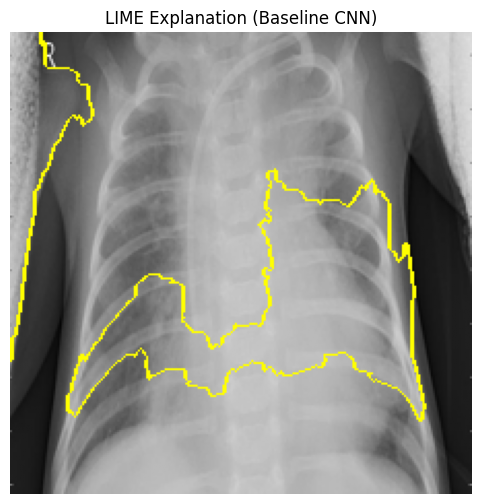

In [103]:
#Visualize LIME explanation
temp, mask = explanation.get_image_and_mask(
    label=1,              # PNEUMONIA
    positive_only=True,
    hide_rest=False,
    num_features=5
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation (Baseline CNN)")
plt.axis("off")
plt.show()


In [104]:

import torch
import numpy as np
import matplotlib.pyplot as plt

from lime import lime_image
from skimage.segmentation import mark_boundaries


In [105]:
#Prediction function for VGG16
def predict_vgg16(images):
    model_vgg.eval()

    # images: (N, H, W, 3) from LIME
    images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)

    with torch.no_grad():
        outputs = model_vgg(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

    # Return probabilities for both classes
    # [NORMAL, PNEUMONIA]
    return np.concatenate([1 - probs, probs], axis=1)


In [106]:
#Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()


In [107]:
#Run LIME on ONE test image
explanation_vgg = explainer.explain_instance(
    img_np,                    # shape (224,224,3)
    predict_vgg16,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)


  0%|          | 0/1000 [00:00<?, ?it/s]

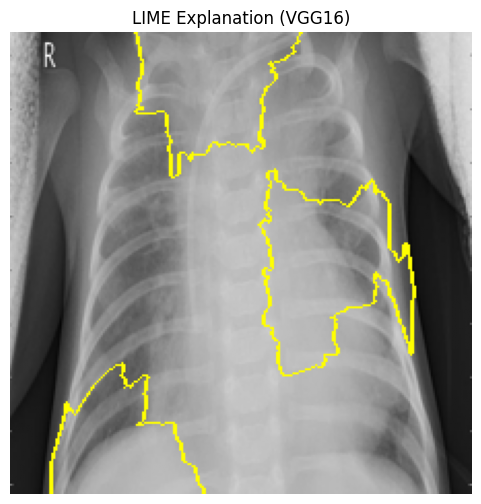

In [108]:
#Visualize LIME result (PNEUMONIA)
temp, mask = explanation_vgg.get_image_and_mask(
    label=1,                   # 1 = PNEUMONIA
    positive_only=True,
    hide_rest=False,
    num_features=5
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation (VGG16)")
plt.axis("off")
plt.show()


In [109]:
#Prediction function for ResNet50
def predict_resnet(images):
    model_resnet.eval()

    images = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)

    with torch.no_grad():
        outputs = model_resnet(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

    return np.concatenate([1 - probs, probs], axis=1)


In [110]:
#Run LIME
explanation_resnet = explainer.explain_instance(
    img_np,
    predict_resnet,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)


  0%|          | 0/1000 [00:00<?, ?it/s]

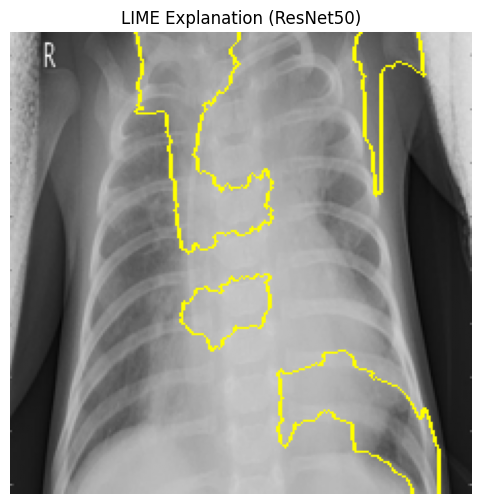

In [111]:
#Visualize LIME result
temp, mask = explanation_resnet.get_image_and_mask(
    label=1,                  # PNEUMONIA
    positive_only=True,
    hide_rest=False,
    num_features=5
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation (ResNet50)")
plt.axis("off")
plt.show()
